# 03. ベータ二項モデル — ベイズ推定のフルコース

## この章で分かること

- ベイズのフロー(仮説→事前→データ→尤度→事後→意思決定)を **1 つのモデルで一周** する
- 事後分布が手で書ける魔法: $\mathrm{Beta}(\alpha, \beta) \to \mathrm{Beta}(\alpha + x,\ \beta + n - x)$
- 点推定 3 兄弟(**MAP・事後平均・中央値**)と **信用区間**
- データが増えると事前の影響が消えていく様子
- 実務応用: **コンバージョン率推定** と **A/B テスト**(どちらが勝っている確率)

本書のコア章です。ここが腑に落ちれば、残りの章は全部この変奏です。

## 1. モデル — 仮説と事前分布

**仮説**: コインの表率(または CVR)$\theta$ は $[0, 1]$ のどこかにある。

**モデル**(尤度と事前):

$$
\theta \sim \mathrm{Beta}(\alpha, \beta)
$$

$$
x \sim \mathrm{Binomial}(n, \theta)
$$

**事後分布**(導出は §9): $n$ 回中 $x$ 回成功を見たら

$$
\theta \mid x \sim \mathrm{Beta}(\alpha + x,\ \beta + n - x)
$$

つまり更新規則は **「成功数を $\alpha$ に、失敗数を $\beta$ に足すだけ」**。
ベータ分布の $\alpha, \beta$ は「すでに見た成功・失敗数」(02 章)— その読み方がそのまま更新則になります。

In [1]:
# Shared setup.
import matplotlib.pyplot as plt
import numpy as np
import plotly.io as pio
from scipy import stats

from bayes_textbook import visualization as viz
from bayes_textbook.conjugacy import BetaBinomial
from bayes_textbook.simulation import make_ab_test_data, prob_a_beats_b

pio.renderers.default = "plotly_mimetype+notebook_connected"
rng = np.random.default_rng(42)
np.set_printoptions(precision=4, suppress=True)

## 2. データと更新 — コイン投げ

真の表率 0.65 のコイン(私たちは知らない)を 50 回投げ、事前 $\mathrm{Beta}(2, 2)$ から更新します。

data: 28 heads, 22 tails out of 50


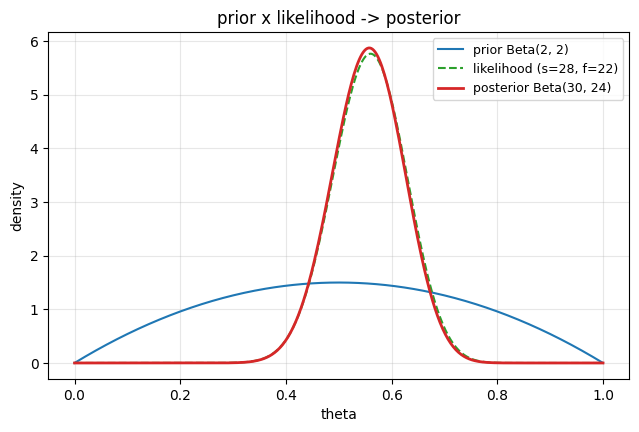

posterior: Beta(30, 24),  mean = 0.556  (true = 0.65)


In [2]:
# Flip a coin with hidden true rate 0.65, then update Beta(2, 2).
true_theta = 0.65
flips = (rng.random(50) < true_theta).astype(int)
s, f = int(flips.sum()), int(len(flips) - flips.sum())
print(f"data: {s} heads, {f} tails out of {len(flips)}")

prior = BetaBinomial(2, 2)
post = prior.update(s, f)
viz.plot_prior_likelihood_posterior(prior, s, f)
plt.title("prior x likelihood -> posterior")
plt.show()
print(f"posterior: Beta({post.alpha:g}, {post.beta:g}),  mean = {post.mean:.3f}  (true = {true_theta})")

事後分布は尤度(データの声)と事前分布(最初の信念)の間に立ちます。
$n = 50$ ではすでに尤度がかなり支配的です。

### 逐次更新 — 1 枚ずつめくる

ベイズ更新は「全部まとめて」でも「1 回ずつ」でも同じ結果になります(更新の合成則)。
投げるたびに分布が尖っていく様子:

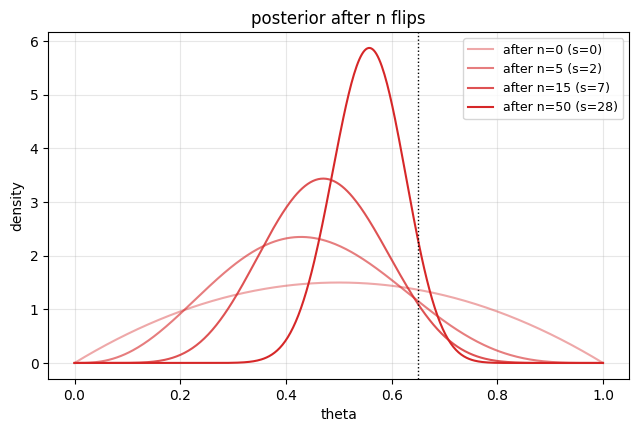

In [3]:
# Sequential updating: the posterior sharpens flip by flip.
viz.plot_beta_binomial_update(prior, flips, checkpoints=(0, 5, 15, None))
plt.title("posterior after n flips")
plt.axvline(true_theta, color="k", ls=":", lw=1)
plt.show()

In [4]:
# Plotly slider version (works in the static HTML too): scrub through n.
theta_grid = np.linspace(0.001, 0.999, 300)
frames = []
for n_seen in [0, 2, 5, 10, 20, 35, 50]:
    s_n = int(flips[:n_seen].sum())
    p_n = prior.update(s_n, n_seen - s_n)
    frames.append((f"{n_seen}",
                   [("posterior", p_n.dist.pdf(theta_grid), None),
                    ("prior", prior.dist.pdf(theta_grid), "dash")]))
fig = viz.plotly_curve_slider(theta_grid, frames, slider_name="flips seen",
                              title="belief sharpens as data arrives")
fig.update_xaxes(title="theta")
fig.show()

## 3. 事後分布から答えを取り出す — 点推定と信用区間

事後分布そのものが答えですが、要約が要る場面では:

- **事後平均**: $\dfrac{\alpha + x}{\alpha + \beta + n}$ — 二乗損失で最適
- **MAP(事後最頻値)**: $\dfrac{\alpha + x - 1}{\alpha + \beta + n - 2}$ — 「一番ありそうな 1 点」
- **95% 信用区間**: 「$\theta$ がこの区間にある確率が 95%」と **そのまま言える** 区間
  (頻度主義の信頼区間との決定的な違い)

posterior mean = 0.5556
MAP            = 0.5577
median         = 0.5562
95% credible interval = [0.4228, 0.6844]


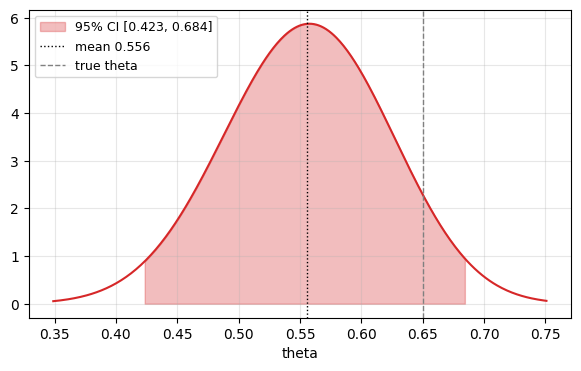

In [5]:
# Point estimates and the credible interval, all read off the posterior.
lo, hi = post.credible_interval(0.95)
print(f"posterior mean = {post.mean:.4f}")
print(f"MAP            = {post.map:.4f}")
print(f"median         = {post.dist.ppf(0.5):.4f}")
print(f"95% credible interval = [{lo:.4f}, {hi:.4f}]")

viz.plot_credible_interval(post)
plt.axvline(true_theta, color="gray", ls="--", lw=1, label="true theta")
plt.legend(fontsize=9)
plt.show()

## 4. 事前分布の影響 — データとの綱引き

同じデータ(7 勝 3 敗)でも、事前分布が違えば事後は違います。
ただし **データが増えるほど事前の影は薄れます**。3 つの事前で比較:

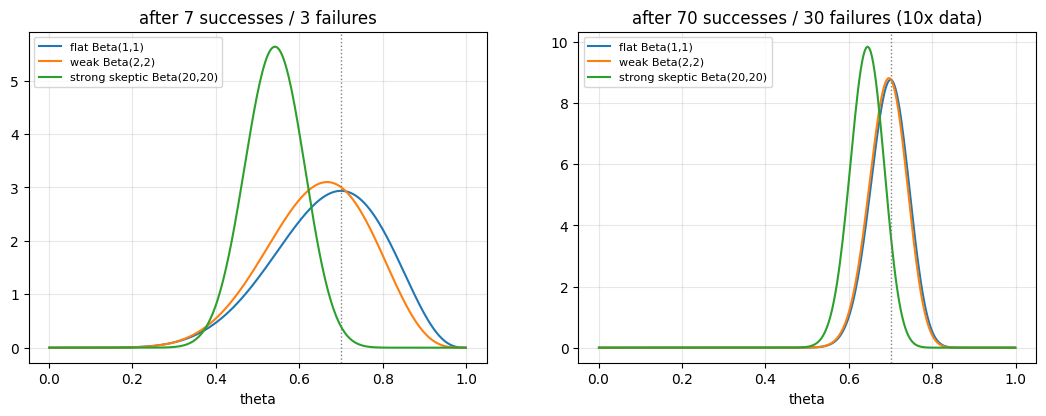

In [6]:
# Same data, three different priors; then watch the prior wash out as n grows.
priors = {
    "flat Beta(1,1)": BetaBinomial(1, 1),
    "weak Beta(2,2)": BetaBinomial(2, 2),
    "strong skeptic Beta(20,20)": BetaBinomial(20, 20),
}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
th = np.linspace(0.001, 0.999, 300)
for name, pr in priors.items():
    axes[0].plot(th, pr.update(7, 3).dist.pdf(th), label=name)
    axes[1].plot(th, pr.update(70, 30).dist.pdf(th), label=name)
axes[0].set_title("after 7 successes / 3 failures")
axes[1].set_title("after 70 successes / 30 failures (10x data)")
for ax in axes:
    ax.axvline(0.7, color="gray", ls=":", lw=1)
    ax.set_xlabel("theta"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.show()

左($n=10$)では事前で答えが大きく動きますが、右($n=100$)ではほぼ一致 —
**データは最終的に事前に勝つ**。事後平均は実は加重平均になっています:

$$
\mathbb{E}[\theta \mid x] = w \cdot \frac{x}{n} + (1 - w) \cdot \frac{\alpha}{\alpha + \beta},
\qquad w = \frac{n}{\alpha + \beta + n}
$$

データの重み $w$ は $n$ とともに 1 に近づきます。$\alpha + \beta$ は
**「事前分布が何個分のデータに相当するか」**(擬似データ数)と読めます。

### インタラクティブ(JupyterLab のみ)

事前 $(\alpha, \beta)$ と成功・失敗数をスライダーで動かして、3 本の曲線の綱引きを体感してください。

In [7]:
# Interactive (JupyterLab only): prior and data sliders.
from bayes_textbook.widgets import interactive_beta_binomial

interactive_beta_binomial()

interactive(children=(FloatSlider(value=2.0, description='alpha', max=30.0, min=0.5, step=0.5), FloatSlider(va…

<function bayes_textbook.widgets.interactive_beta_binomial.<locals>.draw(alpha, beta, successes, failures)>

## 5. 応用 1 — コンバージョン率の推定

EC サイトのあるボタンの CVR を推定します。1,000 訪問で 52 コンバージョン。
点推定なら 5.2% ですが、ベイズなら「5.2% の周りにどれだけ不確実性があるか」まで持てます。

In [8]:
# CVR estimation: the posterior carries the uncertainty, not just 5.2%.
visits, conversions = 1000, 52
cvr_post = BetaBinomial(1, 1).update(conversions, visits - conversions)
lo, hi = cvr_post.credible_interval(0.95)
print(f"CVR posterior mean = {cvr_post.mean:.4f},  95% CI = [{lo:.4f}, {hi:.4f}]")

# Decision-ready probabilities, straight from the posterior:
print(f"P(CVR > 5%)  = {1 - cvr_post.dist.cdf(0.05):.3f}")
print(f"P(CVR > 6%)  = {1 - cvr_post.dist.cdf(0.06):.3f}")

CVR posterior mean = 0.0529,  95% CI = [0.0399, 0.0676]
P(CVR > 5%)  = 0.646
P(CVR > 6%)  = 0.157


「CVR が 5% を超えている確率は 71%」のような文は、事後分布があるからこそ言えます。
閾値を使う意思決定(改善を採用するか)に直結する形です。

## 6. 応用 2 — A/B テスト: B が勝っている確率

新デザイン B は旧デザイン A より良いのか。データ(`data/ab_test.csv` と同じもの)から
各バリアントの事後分布を作り、**モンテカルロで $P(\theta_B > \theta_A)$** を直接計算します。

頻度主義の p 値と違い、答えは「B が勝っている確率」そのもの —
ビジネスの問いにそのまま答える形になっています。

In [9]:
# A/B test: posterior for each arm, then Monte Carlo P(B beats A).
ab = make_ab_test_data()        # same generator as data/ab_test.csv
print(ab)

post_a = BetaBinomial(1, 1).update(
    int(ab.loc[0, "conversions"]), int(ab.loc[0, "visitors"] - ab.loc[0, "conversions"]))
post_b = BetaBinomial(1, 1).update(
    int(ab.loc[1, "conversions"]), int(ab.loc[1, "visitors"] - ab.loc[1, "conversions"]))

p_b_wins = prob_a_beats_b(post_b, post_a, n=200_000)
print(f"\nP(B beats A) = {p_b_wins:.3f}")

  variant  visitors  conversions
0       A      1000           49
1       B      1000           60

P(B beats A) = 0.862


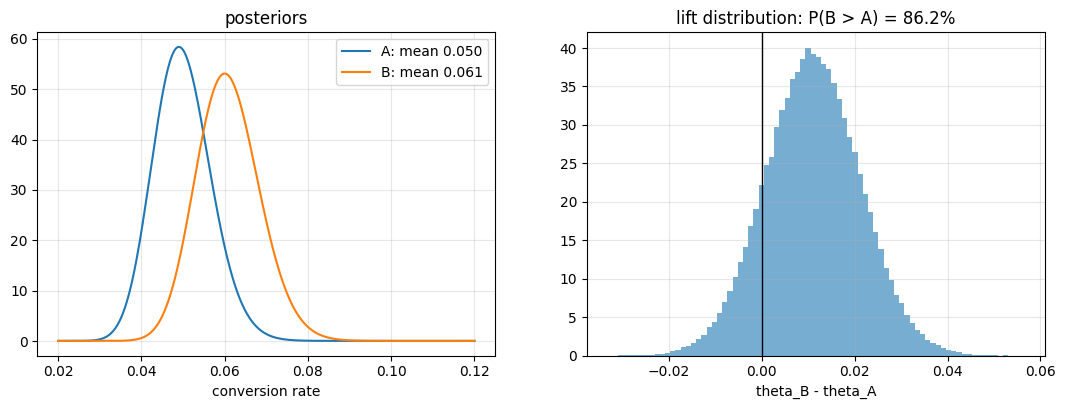

expected lift = 0.0110,  95% CI = [-0.0090, 0.0310]


In [10]:
# The two posteriors, and the Monte Carlo distribution of the lift B - A.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
th = np.linspace(0.02, 0.12, 400)
axes[0].plot(th, post_a.dist.pdf(th), label=f"A: mean {post_a.mean:.3f}")
axes[0].plot(th, post_b.dist.pdf(th), label=f"B: mean {post_b.mean:.3f}")
axes[0].set_xlabel("conversion rate"); axes[0].set_title("posteriors")
axes[0].grid(alpha=0.3); axes[0].legend()

lift = post_b.sample(200_000, seed=1) - post_a.sample(200_000, seed=2)
axes[1].hist(lift, bins=80, density=True, alpha=0.6)
axes[1].axvline(0, color="k", lw=1)
axes[1].set_xlabel("theta_B - theta_A")
axes[1].set_title(f"lift distribution: P(B > A) = {p_b_wins:.1%}")
axes[1].grid(alpha=0.3)
plt.show()
print(f"expected lift = {lift.mean():.4f},  95% CI = [{np.quantile(lift, 0.025):.4f}, {np.quantile(lift, 0.975):.4f}]")

リフト分布の一部はまだ 0 の左側にあります。
「B 採用」と即断する前に、**追加データでどれだけ確信が上がるか** も同じ枠組みで試算できます
(事後を事前にして将来データを足すだけ)。これが逐次的な実験設計のベイズ流です。

## 7. 信用区間の検算 — カバレッジ・シミュレーション

「95% 信用区間」は本当に 95% 当たるのか。
真の $\theta$ を事前分布から引き、データを生成し、区間が真値を含む割合を数えます。
(事前分布が正しい設定なら、ベイズの信用区間は構成上ちょうど 95% を含みます。)

In [11]:
# Coverage check: with theta drawn from the prior, 95% CIs contain it ~95% of the time.
def coverage(prior, n_trials=4000, n_obs=30, seed=0):
    r = np.random.default_rng(seed)
    hits = 0
    thetas = prior.dist.rvs(n_trials, random_state=r)
    xs = r.binomial(n_obs, thetas)
    for theta_true, x in zip(thetas, xs, strict=True):
        lo, hi = prior.update(int(x), n_obs - int(x)).credible_interval(0.95)
        hits += lo <= theta_true <= hi
    return hits / n_trials

print(f"empirical coverage = {coverage(BetaBinomial(2, 2)):.3f}  (target 0.95)")

empirical coverage = 0.953  (target 0.95)


## 8. Failure Mode — 事前分布の選び方で事故るとき

- **強すぎる事前 + 少ないデータ**: 事後がほぼ事前のまま。「データを見た気になる」のが最悪。
  → 事前の擬似データ数 $\alpha + \beta$ を常に意識する。
- **ゼロを排除する事前**: たとえば $\mathrm{Beta}(0.5, 0.5)$ は端に質量があるが、
  「$\theta = 0$ はあり得ない」と決め打つ事前は、本当にゼロのとき永遠に気づけない。
- **A/B テストの覗き見**: ベイズでも、止め方によっては期待損失を見誤る。
  $P(B > A)$ だけでなく **期待リフトと損失** を併用するのが実務の定石(09 章)。

## 9. 導出(なぜ Beta + Binomial で閉じるのか)

事後分布はベイズの定理から:

$$
p(\theta \mid x) \propto p(x \mid \theta)\, p(\theta)
\propto \theta^{x}(1-\theta)^{n-x} \cdot \theta^{\alpha-1}(1-\theta)^{\beta-1}
= \theta^{\alpha+x-1}(1-\theta)^{\beta+n-x-1}
$$

最後の式は $\mathrm{Beta}(\alpha + x,\ \beta + n - x)$ の核(正規化定数以外)そのもの。
**尤度と事前が同じ「$\theta^{\bullet}(1-\theta)^{\bullet}$」という形をしている** から、
掛け算しても族から出ない — これが共役性です(04 章で一般化)。

## 10. まとめ

- ベータ二項モデルの更新則: **成功数を $\alpha$ に、失敗数を $\beta$ に足すだけ**。
- 事後平均は「データの率」と「事前の率」の加重平均。重みは $n$ vs 擬似データ数 $\alpha+\beta$。
- 点推定(MAP・平均・中央値)と信用区間は、すべて事後分布から読み出す。
- A/B テストは「**B が勝っている確率**」を直接出せる — 意思決定にそのまま使える形。
- データが増えれば事前は洗い流される。少ないうちは事前を明示できることこそが強み。

## 11. Exercises

1. 事前 $\mathrm{Beta}(1,1)$ で 20 回中 14 回成功。事後分布・事後平均・MAP・95% 信用区間を求めよ。
2. 事後平均の加重平均表現($w = n/(\alpha+\beta+n)$)を、$n=10$ と $n=1000$ で数値確認せよ。
3. 「$\theta > 0.5$ である確率」を、§2 のコイン投げの事後から計算せよ。
4. A/B テストで両腕の訪問数を 10 倍にしたデータを生成し、$P(B > A)$ と
   リフトの信用区間がどう変わるか確認せよ。
5. カバレッジ実験を、**生成に使う事前と推定に使う事前が違う** 設定
   (生成 $\mathrm{Beta}(8,2)$、推定 $\mathrm{Beta}(2,8)$)で行い、カバレッジが崩れることを確認せよ。
6. (発展)損失を `max(0, theta_A - theta_B)` として「B を採用したときの期待損失」を
   モンテカルロで計算せよ。期待損失が十分小さいことを停止基準にする方法を考察せよ。